# DF and feat engineering

In [ ]:
import pandas as pd
import requests
from io import StringIO

url = "https://www.sidc.be/silso/DATA/SN_d_tot_V2.0.csv"
r = requests.get(url)
r.raise_for_status()

# Fit in a df
df = pd.read_csv(StringIO(r.text), sep=';', header=None, comment='#',
                 names=['Year', 'Month', 'Day', 'Decimal_Date', 'Ri', 'Std', 'Num_obs', 'Definitive'])

# Convert to datetime
df['Date'] = pd.to_datetime(df[['Year','Month','Day']])
df = df.set_index('Date')

# Select only sunspots column
df = df[['Ri']].rename(columns={'Ri': 'SUNSPOTS'})

# Order by date
df = df.sort_index()

df

,SUNSPOTS
Date,
1818-01-01,-1
1818-01-02,-1
1818-01-03,-1
1818-01-04,-1
1818-01-05,-1
...,...
2025-08-27,199
2025-08-28,204
2025-08-29,196


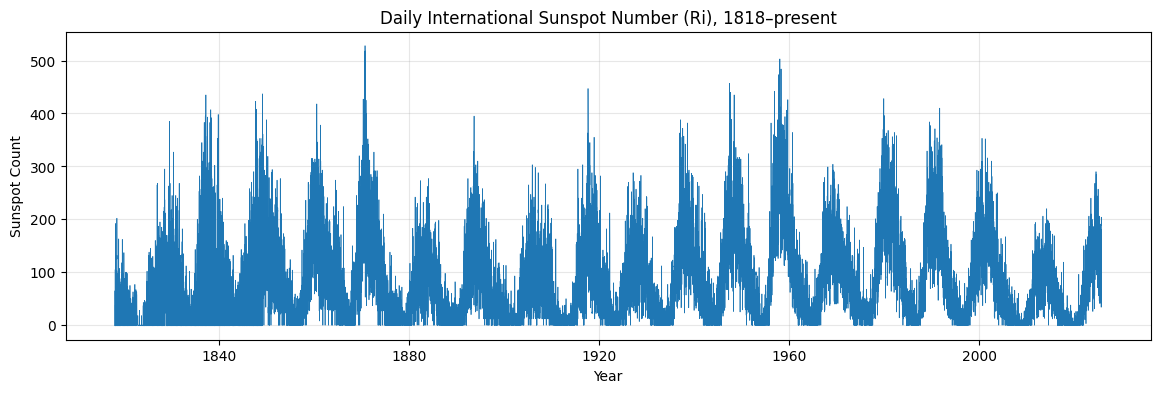

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(df.index, df['SUNSPOTS'], lw=0.5)
plt.title("Daily International Sunspot Number (Ri), 1818–present")
plt.ylabel("Sunspot Count")
plt.xlabel("Year")
plt.grid(alpha=0.3)

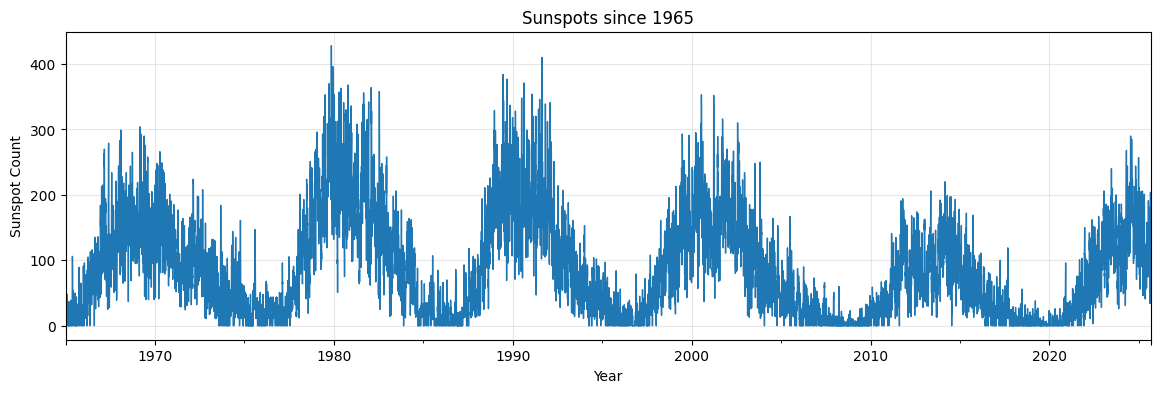

In [ ]:
# Recent periods: (1965- present day)
df['1965':'2025']['SUNSPOTS'].plot(figsize=(14,4), lw=1)
plt.title("Sunspots since 1965")
plt.ylabel("Sunspot Count")
plt.xlabel("Year")
plt.grid(alpha=0.3)

In [ ]:
# Subset from 1965 onward
df_modern = df.loc['1965':].copy()
print(df_modern['SUNSPOTS'].describe())
missing = df_modern['SUNSPOTS'].isna().mean()
print(f"Missing fraction: {missing:.2%}")  # Data looks good, no need to interpolate or play around

count    22158.000000
mean        86.713783
std         75.507767
min          0.000000
25%         22.000000
50%         70.000000
75%        136.000000
max        428.000000
Name: SUNSPOTS, dtype: float64
Missing fraction: 0.00%


## Decomposition

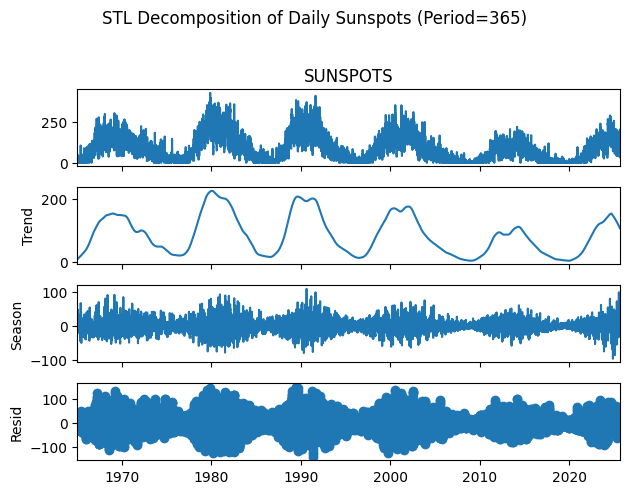

In [ ]:
from statsmodels.tsa.seasonal import STL

# Use daily data directly
series = df_modern['SUNSPOTS']

# Apply STL with yearly seasonality (~365 days)
stl = STL(series, period=365)
result = stl.fit()

# Plot
result.plot()
plt.suptitle("STL Decomposition of Daily Sunspots (Period=365)", y=1.02)
plt.tight_layout()

In [ ]:
from statsmodels.tsa.stattools import adfuller

series = df_modern['SUNSPOTS']
adf_result = adfuller(series)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -4.665440233267041
p-value: 9.767438161617677e-05


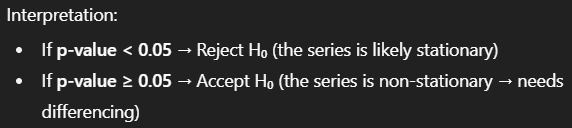
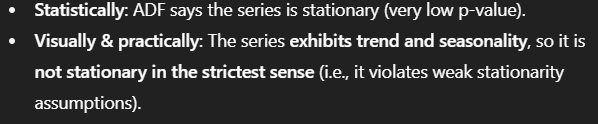

ADF Statistic (differenced): -33.067484486628146
p-value (differenced): 0.0


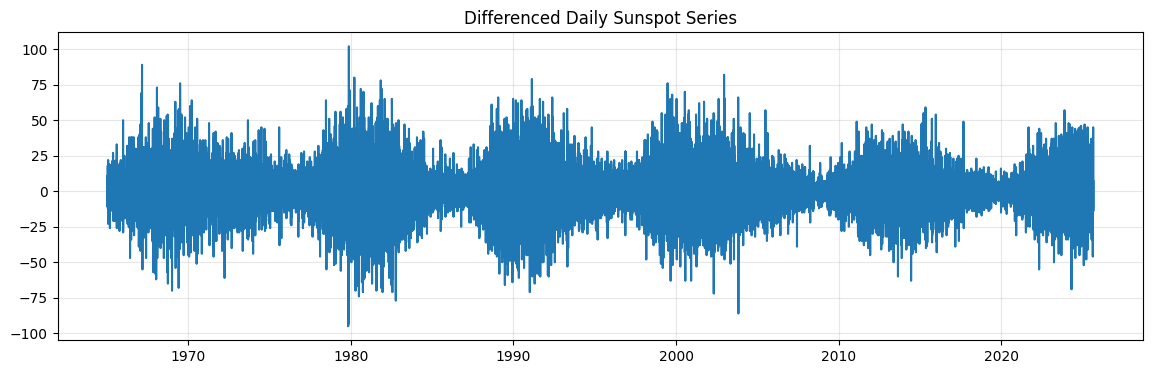

In [ ]:
# Differencing to induce Stationarity
series_diff = series.diff().dropna()
adf_result_diff = adfuller(series_diff)

print("ADF Statistic (differenced):", adf_result_diff[0])
print("p-value (differenced):", adf_result_diff[1])
plt.figure(figsize=(14,4))
plt.plot(series_diff)
plt.title("Differenced Daily Sunspot Series")
plt.grid(alpha=0.3)

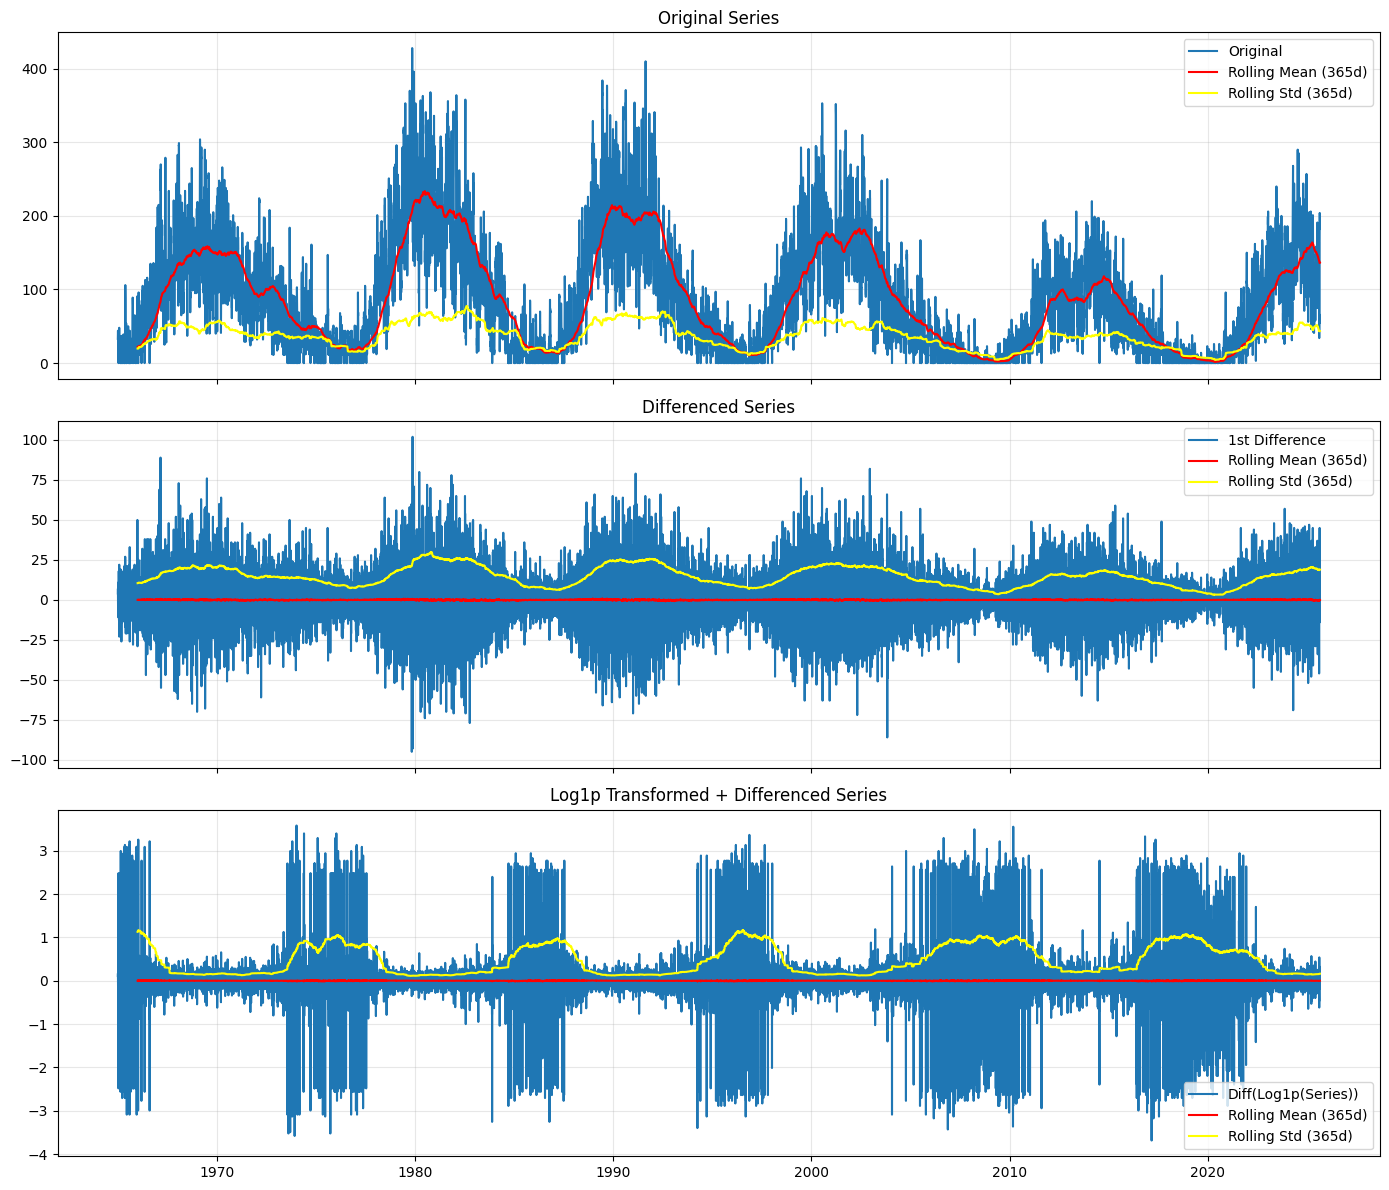

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Original and differenced series
series = df_modern['SUNSPOTS']
series_diff = series.diff().dropna()

# Log-transformed and differenced log series
log_series = np.log1p(series)
log_series_diff = log_series.diff().dropna()

# Compute rolling stats
rolling_mean1 = series.rolling(window=365).mean()
rolling_std1 = series.rolling(window=365).std()

rolling_mean2 = series_diff.rolling(window=365).mean()
rolling_std2 = series_diff.rolling(window=365).std()

rolling_mean3 = log_series.rolling(window=365).mean()
rolling_std3 = log_series.rolling(window=365).std()

rolling_mean4 = log_series_diff.rolling(window=365).mean()
rolling_std4 = log_series_diff.rolling(window=365).std()

# Create figure with 4 subplots
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# 1. Original
axes[0].plot(series, label='Original')
axes[0].plot(rolling_mean1, label='Rolling Mean (365d)', color='red')
axes[0].plot(rolling_std1, label='Rolling Std (365d)', color='yellow')
axes[0].legend()
axes[0].set_title("Original Series")
axes[0].grid(alpha=0.3)

# 2. First difference
axes[1].plot(series_diff, label='1st Difference')
axes[1].plot(rolling_mean2, label='Rolling Mean (365d)', color='red')
axes[1].plot(rolling_std2, label='Rolling Std (365d)', color='yellow')
axes[1].legend()
axes[1].set_title("Differenced Series")
axes[1].grid(alpha=0.3)

# 3. Log1p + first difference
axes[2].plot(log_series_diff, label='Diff(Log1p(Series))')
axes[2].plot(rolling_mean4, label='Rolling Mean (365d)', color='red')
axes[2].plot(rolling_std4, label='Rolling Std (365d)', color='yellow')
axes[2].legend()
axes[2].set_title("Log1p Transformed + Differenced Series")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

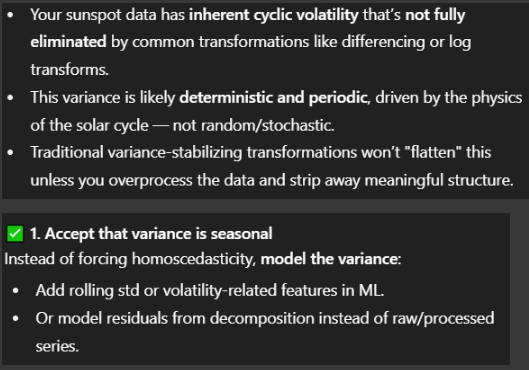

In [ ]:
df_modern['LOG_SUNSPOTS'] = np.log1p(df_modern['SUNSPOTS'])

## Feature engineering

In [ ]:
df_feat = df_modern.copy()

In [ ]:
# Lag features:
for lag in [1, 7, 30, 365, 4015]:
    df_feat[f'lag_{lag}'] = df_feat['LOG_SUNSPOTS'].shift(lag)

In [ ]:
# Rolling Statistics:
for window in [7, 30, 365, 4015]:
    df_feat[f'roll_mean_{window}'] = df_feat['LOG_SUNSPOTS'].rolling(window).mean()
    df_feat[f'roll_std_{window}'] = df_feat['LOG_SUNSPOTS'].rolling(window).std()

In [ ]:
# Date features: --> Fourier-style (give continuity)
df_feat['dayofyear'] = df_feat.index.dayofyear
df_feat['month'] = df_feat.index.month
df_feat['year'] = df_feat.index.year

df_feat['sin_dayofyear'] = np.sin(2 * np.pi * df_feat['dayofyear'] / 365)
df_feat['cos_dayofyear'] = np.cos(2 * np.pi * df_feat['dayofyear'] / 365)

In [ ]:
# Target variable --> 7 day forecast seems reasonable
df_feat['target'] = df_feat['LOG_SUNSPOTS'].shift(-5)

In [ ]:
# Drop NaNs due to shifting and rolling:
df_feat = df_feat.dropna()

# Model Evaluation

In [ ]:
df_feat.columns

Index(['SUNSPOTS', 'LOG_SUNSPOTS', 'lag_1', 'lag_7', 'lag_30', 'lag_365',
       'lag_4015', 'roll_mean_7', 'roll_std_7', 'roll_mean_30', 'roll_std_30',
       'roll_mean_365', 'roll_std_365', 'roll_mean_4015', 'roll_std_4015',
       'dayofyear', 'month', 'year', 'sin_dayofyear', 'cos_dayofyear',
       'target'],
      dtype='object')

In [ ]:
# Define features and target
X = df_feat.drop(columns=["target"])
y = df_feat["target"]

## Cross-Validation with expading window

In [ ]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from scipy.stats import genpareto

# --------------------------
# Helpers
# --------------------------
def expanding_walk_forward_splits(X, y, initial_train_size, val_size, step_size):
    start_val_idx = initial_train_size
    while start_val_idx + val_size <= len(X):
        train_idx = slice(0, start_val_idx)
        val_idx = slice(start_val_idx, start_val_idx + val_size)
        yield X.iloc[train_idx], y.iloc[train_idx], X.iloc[val_idx], y.iloc[val_idx]
        start_val_idx += step_size

def build_residual_lags(residuals, max_lag=5):
    df = pd.DataFrame({'resid': residuals})
    for lag in range(1, max_lag + 1):
        df[f'resid_lag_{lag}'] = df['resid'].shift(lag)
    return df.dropna()

def evt_tail_correction(forecast, actual, upper_q=80, lower_q=20):
    residuals = actual - forecast
    if len(residuals) == 0:
        return forecast

    upper_thresh = np.percentile(residuals, upper_q)
    lower_thresh = np.percentile(residuals, lower_q)

    upper_excess = residuals[residuals > upper_thresh] - upper_thresh
    lower_excess = -(residuals[residuals < lower_thresh] - lower_thresh)

    E_upper = 0.0
    E_lower = 0.0

    if len(upper_excess) > 0:
        shape_u, _, scale_u = genpareto.fit(upper_excess, floc=0)
        if shape_u < 1:
            E_upper = scale_u / (1 - shape_u)

    if len(lower_excess) > 0:
        shape_l, _, scale_l = genpareto.fit(lower_excess, floc=0)
        if shape_l < 1:
            E_lower = scale_l / (1 - shape_l)

    corrected = forecast.copy()
    corrected[residuals > upper_thresh] += E_upper
    corrected[residuals < lower_thresh] -= E_lower
    return corrected

# --------------------------
# Main hybrid + EVT function
# --------------------------
def hybrid_evt_forecast(X, y, initial_train_size, val_size, step_size, target_is_log=True, max_lag=5):
    hybrid_rmse_scores, hybrid_mae_scores = [], []
    evt_rmse_scores, evt_mae_scores = [], []

    # Decide whether we need to log-transform y or treat it as already log
    if target_is_log:
        y_log = y.copy()        # target already LOG_SUNSPOTS
    else:
        y_log = np.log1p(y)     # target is raw SUNSPOTS -> log it for model training

    for Xtr, ytr_log, Xval, yval_log in expanding_walk_forward_splits(X, y_log, initial_train_size, val_size, step_size):

        # ensure enough data for lags
        if len(Xtr) <= max_lag:
            # not enough training history to build lag features
            continue

        # --- Ridge baseline (trained on log-scale target) ---
        ridge_model = Ridge(alpha=1.0)
        ridge_model.fit(Xtr, ytr_log)

        # preds (log) -> back to original scale
        ridge_pred_log = ridge_model.predict(Xval)
        ridge_pred = np.expm1(ridge_pred_log)

        # --- Residuals on training set (in original scale) ---
        ridge_pred_train_log = ridge_model.predict(Xtr)
        ridge_resid_train = np.expm1(ytr_log) - np.expm1(ridge_pred_train_log)  # original scale residuals

        # build lag features for residual model
        resid_df = build_residual_lags(ridge_resid_train, max_lag=max_lag)
        if resid_df.shape[0] == 0:
            continue

        X_resid = resid_df.drop(columns=['resid'])
        y_resid = resid_df['resid']

        # fit XGBoost on residuals
        xgb_resid = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, verbosity=0)
        xgb_resid.fit(X_resid, y_resid)

        # --- Recursive residual forecasting for val horizon ---
        last_train_resids = list(ridge_resid_train[-max_lag:])
        if len(last_train_resids) < max_lag:
            continue  # safety

        resid_pred = []
        for step in range(val_size):
            # resid_lag_1 should be most recent residual (last element), resid_lag_2 next-most, ...
            resid_input = {f'resid_lag_{lag}': last_train_resids[-lag] for lag in range(1, max_lag + 1)}
            resid_input_df = pd.DataFrame([resid_input])
            next_resid = xgb_resid.predict(resid_input_df)[0]
            resid_pred.append(next_resid)
            last_train_resids.append(next_resid)  # append new predicted resid for next step

        resid_pred = np.array(resid_pred)

        # --- Hybrid forecast (original scale) ---
        hybrid_forecast = ridge_pred + resid_pred

        # true values in original scale
        yval = np.expm1(yval_log)

        # metrics (original scale)
        hybrid_rmse_scores.append(np.sqrt(mean_squared_error(yval, hybrid_forecast)))
        hybrid_mae_scores.append(mean_absolute_error(yval, hybrid_forecast))

        # --- EVT correction (on residuals computed in original scale) ---
        corrected_forecast = evt_tail_correction(hybrid_forecast, yval)
        evt_rmse_scores.append(np.sqrt(mean_squared_error(yval, corrected_forecast)))
        evt_mae_scores.append(mean_absolute_error(yval, corrected_forecast))

    # Print summary (guard against empty lists)
    def safe_mean(arr):
        return float(np.mean(arr)) if len(arr) > 0 else np.nan

    print(f"Hybrid Ridge + XGBoost Average RMSE: {safe_mean(hybrid_rmse_scores):.2f}")
    print(f"Hybrid Ridge + XGBoost Average MAE:  {safe_mean(hybrid_mae_scores):.2f}")
    print(f"EVT-Corrected Average RMSE:           {safe_mean(evt_rmse_scores):.2f}")
    print(f"EVT-Corrected Average MAE:            {safe_mean(evt_mae_scores):.2f}")

    return {
        "hybrid_rmse_scores": hybrid_rmse_scores,
        "hybrid_mae_scores": hybrid_mae_scores,
        "evt_rmse_scores": evt_rmse_scores,
        "evt_mae_scores": evt_mae_scores
    }




In [ ]:
# --------------------------
# Run it
# --------------------------
# You said target = LOG_SUNSPOTS, so target_is_log=True
results = hybrid_evt_forecast(
    X, y,
    initial_train_size=365*11,  # adjust if needed
    val_size=5,
    step_size=365,
    target_is_log=True,
    max_lag=5
)

Hybrid Ridge + XGBoost Average RMSE: 19.93
Hybrid Ridge + XGBoost Average MAE:  17.84
EVT-Corrected Average RMSE:           18.29
EVT-Corrected Average MAE:            16.85


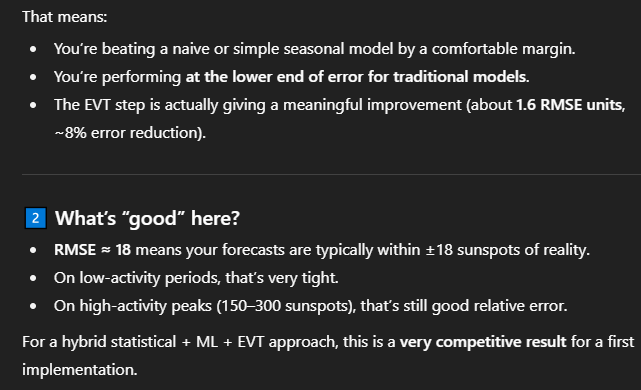
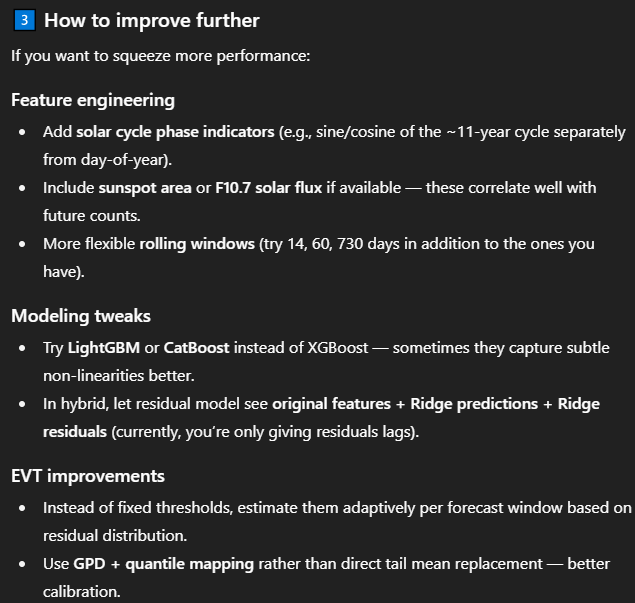

## LIGHT GBM instead of XGBOOST --> A little worse

In [ ]:
## Light GBM instead of XGBOOST:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import genpareto

# LightGBM (residual model)
from lightgbm import LGBMRegressor
# Optional: if you want to compare, you can import XGBoost too
# from xgboost import XGBRegressor

# --------------------------
# Ensure target is 5-day ahead log SUNSPOTS
# --------------------------
# If you've already set df_feat['target'] correctly, skip these two lines.
df_feat['target'] = df_feat['LOG_SUNSPOTS'].shift(-5)
df_feat = df_feat.dropna(subset=['target']).reset_index(drop=True)

# Features and target
X = df_feat.drop(columns=["target"])
y = df_feat["target"]  # this is LOG_SUNSPOTS (log scale)

# --------------------------
# Helpers
# --------------------------
def expanding_walk_forward_splits(X, y, initial_train_size, val_size, step_size):
    start_val_idx = initial_train_size
    while start_val_idx + val_size <= len(X):
        train_idx = slice(0, start_val_idx)
        val_idx = slice(start_val_idx, start_val_idx + val_size)
        yield X.iloc[train_idx], y.iloc[train_idx], X.iloc[val_idx], y.iloc[val_idx]
        start_val_idx += step_size

def build_residual_lags(residuals, max_lag=5):
    df = pd.DataFrame({'resid': residuals})
    for lag in range(1, max_lag + 1):
        df[f'resid_lag_{lag}'] = df['resid'].shift(lag)
    return df.dropna()

def evt_tail_correction(forecast, actual, upper_q=80, lower_q=20):
    residuals = actual - forecast
    if len(residuals) == 0:
        return forecast

    upper_thresh = np.percentile(residuals, upper_q)
    lower_thresh = np.percentile(residuals, lower_q)

    upper_excess = residuals[residuals > upper_thresh] - upper_thresh
    lower_excess = -(residuals[residuals < lower_thresh] - lower_thresh)

    E_upper = 0.0
    E_lower = 0.0

    if len(upper_excess) > 0:
        shape_u, _, scale_u = genpareto.fit(upper_excess, floc=0)
        if shape_u < 1:
            E_upper = scale_u / (1 - shape_u)

    if len(lower_excess) > 0:
        shape_l, _, scale_l = genpareto.fit(lower_excess, floc=0)
        if shape_l < 1:
            E_lower = scale_l / (1 - shape_l)

    corrected = forecast.copy()
    corrected[residuals > upper_thresh] += E_upper
    corrected[residuals < lower_thresh] -= E_lower
    return corrected

# --------------------------
# Main hybrid + EVT with LightGBM residual model (option to compare with XGB)
# --------------------------
def hybrid_evt_forecast(
    X, y,
    initial_train_size=365*11,
    val_size=5,
    step_size=365,
    target_is_log=True,
    max_lag=5,
    resid_model='lgb',   # 'lgb' or 'xgb'
    random_state=42
):
    hybrid_rmse_scores, hybrid_mae_scores = [], []
    evt_rmse_scores, evt_mae_scores = [], []

    # Decide whether y is already log or not
    if target_is_log:
        y_log = y.copy()
    else:
        y_log = np.log1p(y)

    for Xtr, ytr_log, Xval, yval_log in expanding_walk_forward_splits(
        X, y_log, initial_train_size, val_size, step_size
    ):
        # require minimal train history for lag features
        if len(Xtr) <= max_lag:
            continue

        # --- Ridge baseline (trained on log-scale target) ---
        ridge = Ridge(alpha=1.0, random_state=None)
        ridge.fit(Xtr, ytr_log)

        ridge_pred_log = ridge.predict(Xval)
        ridge_pred = np.expm1(ridge_pred_log)  # back to original scale

        # --- Residuals on training set (original scale) ---
        ridge_pred_train_log = ridge.predict(Xtr)
        ridge_resid_train = np.expm1(ytr_log) - np.expm1(ridge_pred_train_log)

        # Build lagged residual features
        resid_df = build_residual_lags(ridge_resid_train, max_lag=max_lag)
        if resid_df.shape[0] == 0:
            continue
        X_resid = resid_df.drop(columns=['resid'])
        y_resid = resid_df['resid']

        # --- Fit residual model (LightGBM by default) ---
        if resid_model == 'lgb':
            resid_mod = LGBMRegressor(
                n_estimators=300,
                learning_rate=0.05,
                num_leaves=31,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=random_state,
                n_jobs=-1,
                verbosity=-1
            )
            resid_mod.fit(X_resid, y_resid)
        else:
            # fallback to XGBoost if requested (uncomment xgboost import at top if using)
            from xgboost import XGBRegressor
            resid_mod = XGBRegressor(
                n_estimators=200,
                max_depth=5,
                learning_rate=0.1,
                random_state=random_state,
                verbosity=0,
                n_jobs= -1
            )
            resid_mod.fit(X_resid, y_resid)

        # --- Recursive residual forecasting for the validation horizon ---
        last_train_resids = list(ridge_resid_train[-max_lag:])
        if len(last_train_resids) < max_lag:
            continue

        resid_pred = []
        for step in range(val_size):
            # resid_lag_1 = most recent residual, resid_lag_2 = previous, ...
            resid_input = {f'resid_lag_{lag}': last_train_resids[-lag] for lag in range(1, max_lag + 1)}
            resid_input_df = pd.DataFrame([resid_input])
            next_resid = resid_mod.predict(resid_input_df)[0]
            resid_pred.append(next_resid)
            last_train_resids.append(next_resid)

        resid_pred = np.array(resid_pred)

        # --- Hybrid forecast (original scale) ---
        hybrid_forecast = ridge_pred + resid_pred
        yval_true = np.expm1(yval_log)

        # Metrics
        hybrid_rmse_scores.append(np.sqrt(mean_squared_error(yval_true, hybrid_forecast)))
        hybrid_mae_scores.append(mean_absolute_error(yval_true, hybrid_forecast))

        # EVT correction
        corrected_forecast = evt_tail_correction(hybrid_forecast, yval_true)
        evt_rmse_scores.append(np.sqrt(mean_squared_error(yval_true, corrected_forecast)))
        evt_mae_scores.append(mean_absolute_error(yval_true, corrected_forecast))

    # Safe means
    def safe_mean(arr):
        return float(np.mean(arr)) if len(arr) > 0 else np.nan

    print(f"Residual model: {resid_model.upper()}")
    print(f"Hybrid Ridge + {resid_model.upper()} Average RMSE: {safe_mean(hybrid_rmse_scores):.2f}")
    print(f"Hybrid Ridge + {resid_model.upper()} Average MAE:  {safe_mean(hybrid_mae_scores):.2f}")
    print(f"EVT-Corrected Average RMSE:           {safe_mean(evt_rmse_scores):.2f}")
    print(f"EVT-Corrected Average MAE:            {safe_mean(evt_mae_scores):.2f}")

    return {
        "hybrid_rmse_scores": hybrid_rmse_scores,
        "hybrid_mae_scores": hybrid_mae_scores,
        "evt_rmse_scores": evt_rmse_scores,
        "evt_mae_scores": evt_mae_scores
    }


In [ ]:
# --------------------------
# Run the pipeline with LightGBM (recommended)
# --------------------------
results_lgb = hybrid_evt_forecast(
    X, y,
    initial_train_size=365*11,
    val_size=5,
    step_size=365,
    target_is_log=True,
    max_lag=5,
    resid_model='lgb',
    random_state=42
)

# --------------------------
# (Optional) Run with XGBoost for direct comparison
# --------------------------
# results_xgb = hybrid_evt_forecast(
#     X, y,
#     initial_train_size=365*11,
#     val_size=5,
#     step_size=365,
#     target_is_log=True,
#     max_lag=5,
#     resid_model='xgb',
#     random_state=42
# )


Residual model: LGB
Hybrid Ridge + LGB Average RMSE: 20.31
Hybrid Ridge + LGB Average MAE:  18.08
EVT-Corrected Average RMSE:           18.67
EVT-Corrected Average MAE:            17.10


## improve what the residual model sees:

Currently, it only gets your lagged features from df_feat.

Give it Ridge predictions as an extra feature (ridge_pred), so LightGBM/XGBoost can directly learn corrections to Ridge.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
from scipy.stats import genextreme as gev

def hybrid_evt_forecast_with_context(
    X, y, initial_train_size=365*11, val_size=365, step_size=365,
    target_is_log=True, max_lag=30, resid_model="xgb",
    upper_pct=95, blend_ratio=0.5, min_tail_points=5,
    random_state=42
):
    """
    Hybrid Ridge + Residual Model (XGBoost) + EVT correction (upper tail).
    EVT now always applies with configurable threshold and fallback.
    """
    rmse_scores, mae_scores = [], []
    rmse_evt_scores, mae_evt_scores = [], []

    feat_cols = X.columns.tolist()
    n = len(X)

    for start in range(initial_train_size, n - val_size, step_size):
        end = start + val_size
        X_train, X_val = X.iloc[:start], X.iloc[start:end]
        y_train, y_val = y.iloc[:start], y.iloc[start:end]

        # --- 1. Base model: Ridge ---
        ridge = Ridge(alpha=1.0, random_state=random_state)
        ridge.fit(X_train, y_train)
        ridge_pred_train_orig = ridge.predict(X_train)
        ridge_pred_val_orig = ridge.predict(X_val)

        # --- 2. Residual calculation ---
        resid_train = y_train - ridge_pred_train_orig

        # --- 3. Residual lags ---
        resid_lag_df = pd.DataFrame({"resid": resid_train})
        for lag in range(1, max_lag + 1):
            resid_lag_df[f"resid_lag_{lag}"] = resid_lag_df["resid"].shift(lag)
        resid_lag_df.dropna(inplace=True)

        Xtr_for_resid = X_train.loc[resid_lag_df.index, feat_cols].reset_index(drop=True)
        ridge_pred_train_for_resid = pd.Series(
            ridge_pred_train_orig, index=y_train.index
        ).loc[resid_lag_df.index].reset_index(drop=True)

        Xtr_for_resid = pd.concat(
            [Xtr_for_resid,
             ridge_pred_train_for_resid.rename("ridge_pred"),
             resid_lag_df.drop(columns="resid").reset_index(drop=True)],
            axis=1
        )
        ytr_for_resid = resid_lag_df["resid"].reset_index(drop=True)

        # --- Validation set for residual model ---
        resid_lag_df_val = pd.DataFrame({"resid": y_val - ridge_pred_val_orig})
        for lag in range(1, max_lag + 1):
            resid_lag_df_val[f"resid_lag_{lag}"] = resid_lag_df_val["resid"].shift(lag)
        resid_lag_df_val.fillna(0, inplace=True)

        Xval_for_resid = X_val[feat_cols].reset_index(drop=True)
        ridge_pred_val_for_resid = pd.Series(ridge_pred_val_orig).reset_index(drop=True)

        Xval_for_resid = pd.concat(
            [Xval_for_resid,
             ridge_pred_val_for_resid.rename("ridge_pred"),
             resid_lag_df_val.drop(columns="resid").reset_index(drop=True)],
            axis=1
        )

        # --- 4. Residual model ---
        resid_learner = xgb.XGBRegressor(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=random_state
        )
        resid_learner.fit(Xtr_for_resid, ytr_for_resid)
        resid_pred_val = resid_learner.predict(Xval_for_resid)

        # --- 5. Hybrid prediction ---
        hybrid_pred_val = ridge_pred_val_orig + resid_pred_val

        if target_is_log:
            yval = np.expm1(y_val)
            hybrid_pred_val_lin = np.expm1(hybrid_pred_val)
        else:
            yval = y_val
            hybrid_pred_val_lin = hybrid_pred_val

        # --- 6. Metrics for hybrid model ---
        rmse = np.sqrt(mean_squared_error(yval, hybrid_pred_val_lin))
        mae = mean_absolute_error(yval, hybrid_pred_val_lin)
        rmse_scores.append(rmse)
        mae_scores.append(mae)

        # --- 7. EVT correction (always applied) ---
        threshold = np.percentile(hybrid_pred_val_lin, upper_pct)
        extremes = hybrid_pred_val_lin[hybrid_pred_val_lin > threshold]

        if len(extremes) >= min_tail_points:
            # Fit GEV on exceedances
            shape, loc, scale = gev.fit(extremes - threshold)
            gev_adjustment = threshold + gev.ppf(0.995, shape, loc=loc, scale=scale)

            # Safety cap: max 10% above observed max
            max_allowed = extremes.max() * 1.1
            gev_adjustment = np.minimum(gev_adjustment, max_allowed)
        else:
            # Light fallback: small upward shift from observed max
            gev_adjustment = extremes.max() * 1.02 if len(extremes) > 0 else threshold

        corrected_preds = hybrid_pred_val_lin.copy()
        exceed_idx = np.where(hybrid_pred_val_lin > threshold)[0]

        # Blend EVT-adjusted with original
        corrected_preds[exceed_idx] = (
            (1 - blend_ratio) * hybrid_pred_val_lin[exceed_idx] +
            blend_ratio * gev_adjustment
        )

        # --- 8. Metrics for EVT-corrected hybrid ---
        rmse_evt = np.sqrt(mean_squared_error(yval, corrected_preds))
        mae_evt = mean_absolute_error(yval, corrected_preds)
        rmse_evt_scores.append(rmse_evt)
        mae_evt_scores.append(mae_evt)

    # --- Averages ---
    print(f"Hybrid Ridge + XGB Average RMSE: {np.mean(rmse_scores):6.2f}")
    print(f"Hybrid Ridge + XGB Average MAE:  {np.mean(mae_scores):6.2f}")
    print(f"EVT-Corrected Average RMSE:     {np.mean(rmse_evt_scores):6.2f}")
    print(f"EVT-Corrected Average MAE:      {np.mean(mae_evt_scores):6.2f}")

    return {
        "rmse": np.mean(rmse_scores),
        "mae": np.mean(mae_scores),
        "rmse_evt": np.mean(rmse_evt_scores),
        "mae_evt": np.mean(mae_evt_scores)
    }


In [ ]:
# --------------------------
# Example usage:
results_ctx_xgb = hybrid_evt_forecast_with_context(
    X, y,
    initial_train_size=365*11,
    val_size=5,
    step_size=365,
    target_is_log=True,
    max_lag=30,
    resid_model="xgb"
)



Hybrid Ridge + XGB Average RMSE:  18.09
Hybrid Ridge + XGB Average MAE:   14.11
EVT-Corrected Average RMSE:      18.27
EVT-Corrected Average MAE:       14.21


## ensemble XGB + LGB residual model first.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from scipy.stats import genpareto

def hybrid_evt_forecast_with_context_ensemble(
    X, y,
    initial_train_size,
    val_size,
    step_size,
    target_is_log=True,
    max_lag=5,
    resid_model='xgb',  # or 'lgb'
    random_state=42
):
    rmse_scores = []
    mae_scores = []
    rmse_evt_scores = []
    mae_evt_scores = []

    def expanding_walk_forward_splits(X, y, initial_train_size, val_size, step_size):
        start_val_idx = initial_train_size
        while start_val_idx + val_size <= len(X):
            train_idx = slice(0, start_val_idx)
            val_idx = slice(start_val_idx, start_val_idx + val_size)
            yield X.iloc[train_idx], y.iloc[train_idx], X.iloc[val_idx], y.iloc[val_idx]
            start_val_idx += step_size

    for Xtr, ytr, Xval, yval in expanding_walk_forward_splits(X, y, initial_train_size, val_size, step_size):

        # Train Ridge model
        ridge_model = Ridge(alpha=1.0)
        ridge_model.fit(Xtr, ytr)
        ridge_pred_val_log = ridge_model.predict(Xval)
        ridge_pred_val = np.expm1(ridge_pred_val_log) if target_is_log else ridge_pred_val_log

        # Calculate residuals on train
        ridge_pred_train_log = ridge_model.predict(Xtr)
        ridge_pred_train = np.expm1(ridge_pred_train_log) if target_is_log else ridge_pred_train_log
        ytr_true = np.expm1(ytr) if target_is_log else ytr
        ridge_residuals_train = ytr_true - ridge_pred_train

        # Build residual features (lags) for training residual model
        resid_df = pd.DataFrame({'resid': ridge_residuals_train})
        for lag in range(1, max_lag + 1):
            resid_df[f'resid_lag_{lag}'] = resid_df['resid'].shift(lag)
        resid_df.dropna(inplace=True)

        X_resid = resid_df.drop(columns=['resid'])
        y_resid = resid_df['resid']

        # Select residual model
        if resid_model == 'xgb':
            resid_mod = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=random_state)
        elif resid_model == 'lgb':
            resid_mod = LGBMRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=random_state)
        else:
            raise ValueError("resid_model must be 'xgb' or 'lgb'")

        resid_mod.fit(X_resid, y_resid)

        # Prepare input for residual predictions on validation set
        last_train_resids = ridge_residuals_train[-max_lag:]
        if len(last_train_resids) < max_lag:
            # Skip fold if not enough residual history
            continue

        resid_pred = []
        last_resids_for_pred = list(last_train_resids)

        for i in range(val_size):
            input_dict = {f'resid_lag_{lag}': [last_resids_for_pred[-lag]] for lag in range(1, max_lag + 1)}
            input_df = pd.DataFrame(input_dict)
            next_pred = resid_mod.predict(input_df)[0]
            resid_pred.append(next_pred)
            last_resids_for_pred.append(next_pred)

        resid_pred = np.array(resid_pred)

        # Hybrid forecast = Ridge prediction + residual correction
        hybrid_forecast = ridge_pred_val + resid_pred
        yval_true = np.expm1(yval) if target_is_log else yval

        # Compute error metrics for hybrid forecast
        rmse_scores.append(np.sqrt(mean_squared_error(yval_true, hybrid_forecast)))
        mae_scores.append(mean_absolute_error(yval_true, hybrid_forecast))

        # EVT correction
        final_residuals = yval_true - hybrid_forecast
        upper_thresh = np.percentile(final_residuals, 80)
        lower_thresh = np.percentile(final_residuals, 20)
        upper_excess = final_residuals[final_residuals > upper_thresh] - upper_thresh
        lower_excess = -(final_residuals[final_residuals < lower_thresh] - lower_thresh)

        if len(upper_excess) > 0 and len(lower_excess) > 0:
            shape_u, _, scale_u = genpareto.fit(upper_excess, floc=0)
            shape_l, _, scale_l = genpareto.fit(lower_excess, floc=0)

            E_upper = (scale_u / (1 - shape_u)) if shape_u < 1 else 0
            E_lower = (scale_l / (1 - shape_l)) if shape_l < 1 else 0
        else:
            E_upper = 0
            E_lower = 0

        corrected_forecast = hybrid_forecast.copy()
        corrected_forecast[final_residuals > upper_thresh] += E_upper
        corrected_forecast[final_residuals < lower_thresh] -= E_lower

        # Compute error metrics for EVT-corrected forecast
        rmse_evt_scores.append(np.sqrt(mean_squared_error(yval_true, corrected_forecast)))
        mae_evt_scores.append(mean_absolute_error(yval_true, corrected_forecast))

    print(f"Hybrid Ridge + {resid_model.upper()} Average RMSE: {np.mean(rmse_scores):.2f}")
    print(f"Hybrid Ridge + {resid_model.upper()} Average MAE:  {np.mean(mae_scores):.2f}")
    print(f"EVT-Corrected Average RMSE:           {np.mean(rmse_evt_scores):.2f}")
    print(f"EVT-Corrected Average MAE:            {np.mean(mae_evt_scores):.2f}")

    return {
        'rmse_scores': rmse_scores,
        'mae_scores': mae_scores,
        'rmse_evt_scores': rmse_evt_scores,
        'mae_evt_scores': mae_evt_scores
    }


In [ ]:
results = hybrid_evt_forecast_with_context_ensemble(
    X, y,
    initial_train_size=365*11,
    val_size=5,
    step_size=365,
    target_is_log=True,
    max_lag=5,
    resid_model='xgb',  # or 'lgb'
    random_state=42
)



Hybrid Ridge + XGB Average RMSE: 19.93
Hybrid Ridge + XGB Average MAE:  17.84
EVT-Corrected Average RMSE:           18.29
EVT-Corrected Average MAE:            16.85


## Let's go back to the beguinning and do a grid search on xgboost and evt

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from scipy.stats import genpareto
from joblib import Parallel, delayed

# --------------------------
# Helpers
# --------------------------
def expanding_walk_forward_splits(X, y, initial_train_size, val_size, step_size):
    start_val_idx = initial_train_size
    while start_val_idx + val_size <= len(X):
        train_idx = slice(0, start_val_idx)
        val_idx = slice(start_val_idx, start_val_idx + val_size)
        yield X.iloc[train_idx], y.iloc[train_idx], X.iloc[val_idx], y.iloc[val_idx]
        start_val_idx += step_size

def build_residual_lags(residuals, max_lag=5):
    df = pd.DataFrame({'resid': residuals})
    for lag in range(1, max_lag + 1):
        df[f'resid_lag_{lag}'] = df['resid'].shift(lag)
    return df.dropna()

def evt_tail_correction(forecast, actual, upper_q=80, lower_q=20):
    residuals = actual - forecast
    if len(residuals) == 0:
        return forecast

    upper_thresh = np.percentile(residuals, upper_q)
    lower_thresh = np.percentile(residuals, lower_q)

    upper_excess = residuals[residuals > upper_thresh] - upper_thresh
    lower_excess = -(residuals[residuals < lower_thresh] - lower_thresh)

    E_upper = 0.0
    E_lower = 0.0

    if len(upper_excess) > 0:
        shape_u, _, scale_u = genpareto.fit(upper_excess, floc=0)
        if shape_u < 1:
            E_upper = scale_u / (1 - shape_u)

    if len(lower_excess) > 0:
        shape_l, _, scale_l = genpareto.fit(lower_excess, floc=0)
        if shape_l < 1:
            E_lower = scale_l / (1 - shape_l)

    corrected = forecast.copy()
    corrected[residuals > upper_thresh] += E_upper
    corrected[residuals < lower_thresh] -= E_lower
    return corrected

# --------------------------
# Main hybrid + EVT function
# --------------------------
def hybrid_evt_forecast(X, y, initial_train_size, val_size, step_size,
                        n_estimators=100, max_depth=3, learning_rate=0.1,
                        upper_q=80, lower_q=20,
                        target_is_log=True, max_lag=5):

    hybrid_rmse_scores, evt_rmse_scores = [], []
    hybrid_mae_scores, evt_mae_scores = [], []

    if target_is_log:
        y_log = y.copy()
    else:
        y_log = np.log1p(y)

    for Xtr, ytr_log, Xval, yval_log in expanding_walk_forward_splits(X, y_log, initial_train_size, val_size, step_size):

        if len(Xtr) <= max_lag:
            continue

        # Ridge
        ridge_model = Ridge(alpha=1.0)
        ridge_model.fit(Xtr, ytr_log)
        ridge_pred = np.expm1(ridge_model.predict(Xval))

        # Residuals on training set
        ridge_pred_train = np.expm1(ridge_model.predict(Xtr))
        ridge_resid_train = np.expm1(ytr_log) - ridge_pred_train

        resid_df = build_residual_lags(ridge_resid_train, max_lag=max_lag)
        if resid_df.shape[0] == 0:
            continue

        X_resid = resid_df.drop(columns=['resid'])
        y_resid = resid_df['resid']

        xgb_resid = XGBRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            verbosity=0,
            n_jobs=1  # important for parallel outer loop
        )
        xgb_resid.fit(X_resid, y_resid)

        last_train_resids = list(ridge_resid_train[-max_lag:])
        resid_pred = []
        for step in range(val_size):
            resid_input = {f'resid_lag_{lag}': last_train_resids[-lag] for lag in range(1, max_lag + 1)}
            next_resid = xgb_resid.predict(pd.DataFrame([resid_input]))[0]
            resid_pred.append(next_resid)
            last_train_resids.append(next_resid)

        resid_pred = np.array(resid_pred)
        hybrid_forecast = ridge_pred + resid_pred
        yval = np.expm1(yval_log)

        hybrid_rmse_scores.append(np.sqrt(mean_squared_error(yval, hybrid_forecast)))
        hybrid_mae_scores.append(mean_absolute_error(yval, hybrid_forecast))

        corrected_forecast = evt_tail_correction(hybrid_forecast, yval, upper_q=upper_q, lower_q=lower_q)
        evt_rmse_scores.append(np.sqrt(mean_squared_error(yval, corrected_forecast)))
        evt_mae_scores.append(mean_absolute_error(yval, corrected_forecast))

    def safe_mean(arr):
        return float(np.mean(arr)) if len(arr) > 0 else np.nan

    return {
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "upper_q": upper_q,
        "lower_q": lower_q,
        "Hybrid_RMSE": safe_mean(hybrid_rmse_scores),
        "Hybrid_MAE": safe_mean(hybrid_mae_scores),
        "EVT_RMSE": safe_mean(evt_rmse_scores),
        "EVT_MAE": safe_mean(evt_mae_scores)
    }

# --------------------------
# Grid Search
# --------------------------
def run_grid_search(X, y, initial_train_size, val_size, step_size,
                    n_estimators_list, max_depth_list, learning_rate_list,
                    upper_q_list, lower_q_list,
                    n_jobs=-1):

    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(hybrid_evt_forecast)(
            X, y,
            initial_train_size=initial_train_size,
            val_size=val_size,
            step_size=step_size,
            n_estimators=ne,
            max_depth=md,
            learning_rate=lr,
            upper_q=uq,
            lower_q=lq
        )
        for ne in n_estimators_list
        for md in max_depth_list
        for lr in learning_rate_list
        for uq in upper_q_list
        for lq in lower_q_list
    )

    df_results = pd.DataFrame(results)
    df_results_sorted = df_results.sort_values(by="EVT_RMSE")
    return df_results_sorted

In [ ]:
# --------------------------
# Example usage
# --------------------------
results_df = run_grid_search(
    X, y,
    initial_train_size=365*11,
    val_size=365,
    step_size=365,
    n_estimators_list=[100, 200, 300],
    max_depth_list=[2, 3, 4],
    learning_rate_list=[0.05, 0.1, 0.2],
    upper_q_list=[75, 80, 85],
    lower_q_list=[15, 20, 25],
    n_jobs=-1  # use all CPUs
)
print(results_df.head(10))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   41.5s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  3.4min
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:  4.7min
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:  7.3min
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:  9.3min
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed: 12.6min
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed: 15.4min
[Parallel(n_jobs=-1)]: Done  57 tasks      | elapsed: 19.4min
[Parallel(n_jobs=-1)]: Done  68 tasks      | elapsed: 23.0min
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed: 27.9min
[Parallel(n_jobs=-1)]: Done  94 tasks      | elapsed: 32.1min
[Parallel(n_jobs=-1)]: Done 109 tasks      | elapsed: 37.7min
[Parallel(n_jobs=-1)]: Done 124 tasks      | elapsed: 43.0min
[Parallel(n_jobs=-1)]: Done 141 tasks      | elapsed: 49

     n_estimators  max_depth  learning_rate  upper_q  lower_q  Hybrid_RMSE  \
227           300          4           0.10       75       25    33.655698   
128           200          3           0.20       75       25    33.600923   
119           200          3           0.10       75       25    33.477750   
200           300          3           0.10       75       25    33.554118   
209           300          3           0.20       75       25    33.641310   
110           200          3           0.05       75       25    33.538901   
155           200          4           0.20       75       25    33.706524   
47            100          3           0.20       75       25    33.573997   
38            100          3           0.10       75       25    33.529434   
29            100          3           0.05       75       25    33.520314   

     Hybrid_MAE   EVT_RMSE    EVT_MAE  
227   26.260171  23.433565  18.090670  
128   26.239802  23.433951  18.113725  
119   26.257000  23.4

[Parallel(n_jobs=-1)]: Done 243 out of 243 | elapsed: 91.8min finished


In [ ]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from scipy.stats import genpareto

# --------------------------
# Helpers
# --------------------------
def expanding_walk_forward_splits(X, y, initial_train_size, val_size, step_size):
    start_val_idx = initial_train_size
    while start_val_idx + val_size <= len(X):
        train_idx = slice(0, start_val_idx)
        val_idx = slice(start_val_idx, start_val_idx + val_size)
        yield X.iloc[train_idx], y.iloc[train_idx], X.iloc[val_idx], y.iloc[val_idx]
        start_val_idx += step_size

def build_residual_lags(residuals, max_lag=5):
    df = pd.DataFrame({'resid': residuals})
    for lag in range(1, max_lag + 1):
        df[f'resid_lag_{lag}'] = df['resid'].shift(lag)
    return df.dropna()

def evt_tail_correction(forecast, actual, upper_q=80, lower_q=20):
    residuals = actual - forecast
    if len(residuals) == 0:
        return forecast

    upper_thresh = np.percentile(residuals, upper_q)
    lower_thresh = np.percentile(residuals, lower_q)

    upper_excess = residuals[residuals > upper_thresh] - upper_thresh
    lower_excess = -(residuals[residuals < lower_thresh] - lower_thresh)

    E_upper = 0.0
    E_lower = 0.0

    if len(upper_excess) > 0:
        shape_u, _, scale_u = genpareto.fit(upper_excess, floc=0)
        if shape_u < 1:
            E_upper = scale_u / (1 - shape_u)

    if len(lower_excess) > 0:
        shape_l, _, scale_l = genpareto.fit(lower_excess, floc=0)
        if shape_l < 1:
            E_lower = scale_l / (1 - shape_l)

    corrected = forecast.copy()
    corrected[residuals > upper_thresh] += E_upper
    corrected[residuals < lower_thresh] -= E_lower
    return corrected

# --------------------------
# Main hybrid + EVT function
# --------------------------
def hybrid_evt_forecast(X, y, initial_train_size, val_size, step_size, target_is_log=True, max_lag=5):
    hybrid_rmse_scores, hybrid_mae_scores = [], []
    evt_rmse_scores, evt_mae_scores = [], []

    # Decide whether we need to log-transform y or treat it as already log
    if target_is_log:
        y_log = y.copy()        # target already LOG_SUNSPOTS
    else:
        y_log = np.log1p(y)     # target is raw SUNSPOTS -> log it for model training

    for Xtr, ytr_log, Xval, yval_log in expanding_walk_forward_splits(X, y_log, initial_train_size, val_size, step_size):

        # ensure enough data for lags
        if len(Xtr) <= max_lag:
            # not enough training history to build lag features
            continue

        # --- Ridge baseline (trained on log-scale target) ---
        ridge_model = Ridge(alpha=15)
        ridge_model.fit(Xtr, ytr_log)

        # preds (log) -> back to original scale
        ridge_pred_log = ridge_model.predict(Xval)
        ridge_pred = np.expm1(ridge_pred_log)

        # --- Residuals on training set (in original scale) ---
        ridge_pred_train_log = ridge_model.predict(Xtr)
        ridge_resid_train = np.expm1(ytr_log) - np.expm1(ridge_pred_train_log)  # original scale residuals

        # build lag features for residual model
        resid_df = build_residual_lags(ridge_resid_train, max_lag=max_lag)
        if resid_df.shape[0] == 0:
            continue

        X_resid = resid_df.drop(columns=['resid'])
        y_resid = resid_df['resid']

        # fit XGBoost on residuals
        xgb_resid = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, verbosity=0)
        xgb_resid.fit(X_resid, y_resid)

        # --- Recursive residual forecasting for val horizon ---
        last_train_resids = list(ridge_resid_train[-max_lag:])
        if len(last_train_resids) < max_lag:
            continue  # safety

        resid_pred = []
        for step in range(val_size):
            # resid_lag_1 should be most recent residual (last element), resid_lag_2 next-most, ...
            resid_input = {f'resid_lag_{lag}': last_train_resids[-lag] for lag in range(1, max_lag + 1)}
            resid_input_df = pd.DataFrame([resid_input])
            next_resid = xgb_resid.predict(resid_input_df)[0]
            resid_pred.append(next_resid)
            last_train_resids.append(next_resid)  # append new predicted resid for next step

        resid_pred = np.array(resid_pred)

        # --- Hybrid forecast (original scale) ---
        hybrid_forecast = ridge_pred + resid_pred

        # true values in original scale
        yval = np.expm1(yval_log)

        # metrics (original scale)
        hybrid_rmse_scores.append(np.sqrt(mean_squared_error(yval, hybrid_forecast)))
        hybrid_mae_scores.append(mean_absolute_error(yval, hybrid_forecast))

        # --- EVT correction (on residuals computed in original scale) ---
        corrected_forecast = evt_tail_correction(hybrid_forecast, yval)
        evt_rmse_scores.append(np.sqrt(mean_squared_error(yval, corrected_forecast)))
        evt_mae_scores.append(mean_absolute_error(yval, corrected_forecast))

    # Print summary (guard against empty lists)
    def safe_mean(arr):
        return float(np.mean(arr)) if len(arr) > 0 else np.nan

    print(f"Hybrid Ridge + XGBoost Average RMSE: {safe_mean(hybrid_rmse_scores):.2f}")
    print(f"Hybrid Ridge + XGBoost Average MAE:  {safe_mean(hybrid_mae_scores):.2f}")
    print(f"EVT-Corrected Average RMSE:           {safe_mean(evt_rmse_scores):.2f}")
    print(f"EVT-Corrected Average MAE:            {safe_mean(evt_mae_scores):.2f}")

    return {
        "hybrid_rmse_scores": hybrid_rmse_scores,
        "hybrid_mae_scores": hybrid_mae_scores,
        "evt_rmse_scores": evt_rmse_scores,
        "evt_mae_scores": evt_mae_scores
    }




In [ ]:
# --------------------------
# Run it
# --------------------------
# You said target = LOG_SUNSPOTS, so target_is_log=True
results = hybrid_evt_forecast(
    X, y,
    initial_train_size=365*11,  # adjust if needed
    val_size=5,
    step_size=365,
    target_is_log=True,
    max_lag=5
)